In [1]:
import json, polars as pl
from pathlib import Path
from IPython.display import Image, Markdown, display
ROOT = Path.cwd().parent
T = ROOT / "reports" / "tables"; F = ROOT / "reports" / "figures"
pl.Config.set_tbl_rows(40); pl.Config.set_tbl_cols(20); pl.Config.set_tbl_width_chars(200)
def show(p): display(Image(filename=str(p)))
def tab(p, cols=None):
    d = pl.read_csv(p); return d.select(cols) if cols else d

# 08 · Final untouched holdout (2025-10-01 → 2026-09-30)
Evaluated once, with the methodology frozen in `docs/final_methodology.md`; the access log records the SHA-256 of that file.

In [2]:
print((ROOT / 'reports' / 'holdout_access_log.jsonl').read_text())

{"utc": "2026-10-07T14:21:37+00:00", "purpose": "final evaluation ETHUSDT", "methodology_sha256": "f890b16b518eb1b25e47ade10b7347d3bf1c5ef807f4929028a9212a6d37a670"}
{"utc": "2026-10-07T14:41:34+00:00", "purpose": "replication evaluation SOLUSDT", "methodology_sha256": "f890b16b518eb1b25e47ade10b7347d3bf1c5ef807f4929028a9212a6d37a670"}



In [3]:
H = T / 'holdout'; json.loads((H / 'summary.json').read_text())['primary_classification_pooled']

{'n': 525540,
 'base_rate': 0.4979525821060243,
 'auc': 0.543606219678212,
 'log_loss': 0.6902045026035231,
 'log_loss_baseline': 0.6931387966964506,
 'brier': 0.2485324424381809,
 'accuracy': 0.5314019865281425,
 'precision': 0.5289816683010772,
 'recall': 0.5379909359786621,
 'f1': 0.533448266062954,
 'ece': 0.002838464205784008,
 'pred_up_share': 0.5064333828062564,
 'ic_spearman': 0.06237439458977318}

In [4]:
tab(H / 'primary_blocks.csv', ['block','valid_start','n_train','n','auc','log_loss','log_loss_baseline','ic_spearman'])

block,valid_start,n_train,n,auc,log_loss,log_loss_baseline,ic_spearman
str,str,i64,i64,f64,f64,f64,f64
"""F1""","""2025-10-01""",90623,132465,0.536336,0.691191,0.693142,0.047266
"""F2""","""2026-01-01""",99455,129585,0.548839,0.689632,0.693147,0.070809
"""F3""","""2026-04-01""",108095,131025,0.549106,0.689599,0.693044,0.07256
"""F4""","""2026-07-01""",116831,132465,0.541203,0.690377,0.693146,0.060704


In [5]:
tab(H / 'backtest_summary.csv', ['strategy','cost','total_return','ann_return','sharpe','sortino','max_drawdown','calmar','n_trades','win_rate','profit_factor','avg_trade_bps','breakeven_cost_bps_per_side','turnover_per_day','exposure','sum_funding'])

strategy,cost,total_return,ann_return,sharpe,sortino,max_drawdown,calmar,n_trades,win_rate,profit_factor,avg_trade_bps,breakeven_cost_bps_per_side,turnover_per_day,exposure,sum_funding
str,str,f64,f64,f64,f64,f64,f64,i64,f64,f64,f64,f64,f64,f64,f64
"""ml""","""gross""",0.674648,0.674648,2.028103,2.7287,-0.128211,5.262004,117461,0.571049,1.057457,0.695352,0.492713,30.408402,0.221922,0.000839
"""momentum""","""gross""",-0.780528,-0.780528,-3.181299,-4.293738,-0.81409,-0.958774,525022,0.471515,0.961402,-0.410271,-0.388955,100.843653,0.609624,0.00143
"""flow_rule""","""gross""",-0.5193,-0.5193,-2.807969,-3.801703,-0.531735,-0.976613,175617,0.463201,0.941357,-0.60028,-0.371192,51.9379,0.311612,0.000671
"""random""","""gross""",0.071753,0.071753,0.909375,1.431571,-0.063835,1.124043,117194,0.499087,1.008894,0.092474,0.05163,38.023379,0.094125,0.000374
"""buy_and_hold""","""gross""",-0.368703,-0.368703,-0.475319,-0.667447,-0.686573,-0.537018,1,NaN,NaN,NaN,-3000.666934,0.00274,1.0,-0.025253
"""ml""","""low""",-0.898197,-0.898197,-8.347202,-8.155045,-0.903148,-0.994518,117461,0.473153,0.700211,-4.350648,0.492713,30.408402,0.221922,0.000839
"""momentum""","""low""",-0.99998,-0.99998,-22.840396,-15.13308,-0.99998,-1.0,525022,0.363309,0.598071,-5.456271,-0.388955,100.843653,0.609624,0.00143
"""flow_rule""","""low""",-0.995976,-0.995976,-21.333686,-14.730554,-0.99604,-0.999936,175617,0.351902,0.573428,-5.64628,-0.371192,51.9379,0.311612,0.000671
"""random""","""low""",-0.967687,-0.967687,-43.36717,-17.531863,-0.967707,-0.999979,117194,0.389841,0.624857,-4.953526,0.05163,38.023379,0.094125,0.000374


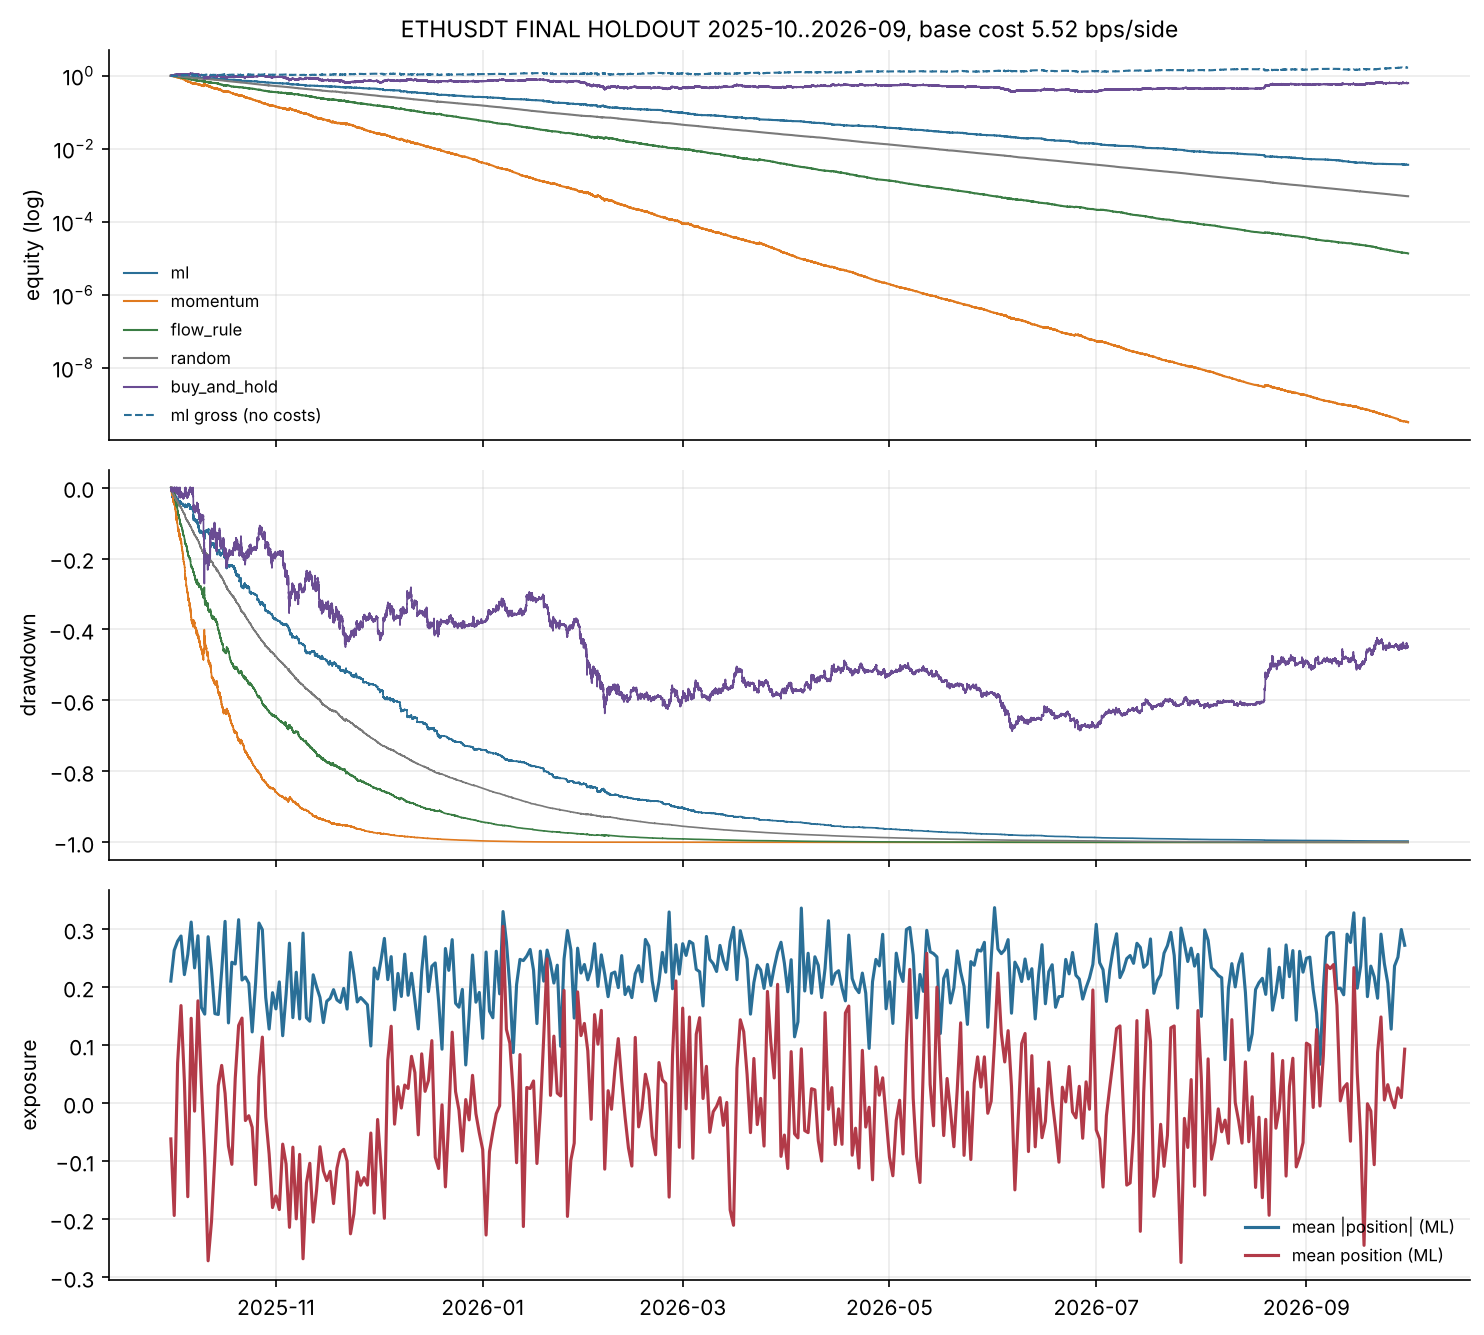

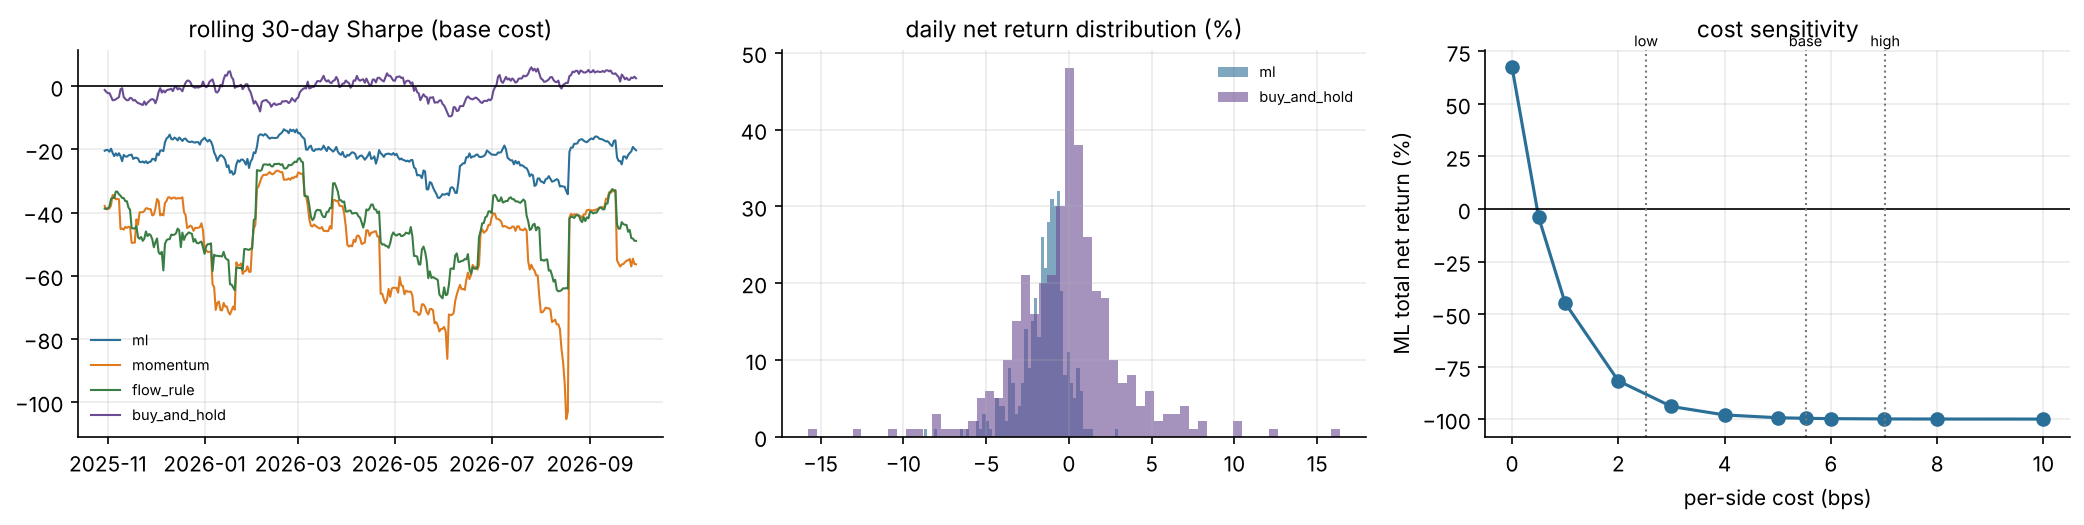

In [6]:
show(F / 'holdout/equity_drawdown_exposure.png'); show(F / 'holdout/rolling_sharpe_distribution_costs.png')

In [7]:
tab(H / 'cost_sensitivity_ml.csv')

cost_bps_per_side,total_return,sharpe
f64,f64,f64
0.0,0.674648,2.028103
0.5,-0.038586,-0.030012
1.0,-0.448054,-2.089785
2.0,-0.818086,-6.203927
3.0,-0.940044,-10.293687
4.0,-0.98024,-14.339007
5.0,-0.993487,-18.32088
5.523,-0.996355,-20.372192
6.0,-0.997854,-22.22178


In [8]:
tab(H / 'regimes.csv'); 

In [9]:
tab(H / 'monthly_stability.csv')

month,auc,log_loss,log_loss_prior,hit_rate,net,gross
str,f64,f64,f64,f64,f64,f64
"""2025-10""",0.533789,0.691562,0.693138,0.527576,-0.459889,0.064121
"""2025-11""",0.521441,0.692899,0.69296,0.514421,-0.359547,0.069516
"""2025-12""",0.551739,0.689165,0.693053,0.538936,-0.515095,-0.021464
"""2026-01""",0.550982,0.689311,0.693107,0.540547,-0.506582,0.010405
"""2026-02""",0.546421,0.690055,0.693126,0.534251,-0.459806,0.04853
"""2026-03""",0.549209,0.689572,0.693135,0.534499,-0.519863,0.061123
"""2026-04""",0.558931,0.688039,0.693146,0.540278,-0.436896,0.059603
"""2026-05""",0.541607,0.690563,0.693042,0.529996,-0.479153,0.028997
"""2026-06""",0.548022,0.690164,0.692693,0.533356,-0.524106,-0.005623


In [10]:
tab(H / 'confirmatory_tests.csv')

signal,h,n,beta_bps_per_sd,t_hac,p_hac,p_holm
str,i64,i64,f64,f64,f64,f64
"""ofi_1""",5,525595,-0.06898,-2.736008,0.006219,0.037314
"""ofi_1""",15,525585,-0.055086,-1.193617,0.232628,0.232628
"""obi_1pct""",5,521401,0.134767,2.027363,0.042625,0.170501
"""obi_1pct""",15,521391,0.311578,1.582624,0.113507,0.227014
"""ofi_15""",5,525595,-0.10049,-2.130614,0.033121,0.165605
"""ofi_15""",15,525585,-0.228927,-1.88409,0.059553,0.178658


In [11]:
tab(H / 'horizons.csv')

model,fset,h,auc,log_loss,log_loss_baseline,ic_spearman
str,str,i64,f64,f64,f64,f64
"""logit""","""A_price""",5,0.533745,0.691752,0.69314,0.05317
"""lgbm""","""A_price""",5,0.537211,0.69101,0.69314,0.05686
"""logit""","""C_plus_flow""",5,0.534383,0.691419,0.69314,0.052697
"""lgbm""","""C_plus_flow""",5,0.536746,0.691059,0.69314,0.056372
"""logit""","""E_all""",5,0.530616,0.692585,0.69314,0.048457
"""lgbm""","""E_all""",5,0.537118,0.690952,0.69314,0.057366
"""logit""","""A_price""",30,0.531616,0.691988,0.693145,0.045899
"""lgbm""","""A_price""",30,0.539879,0.690786,0.693145,0.056632
"""logit""","""C_plus_flow""",30,0.532788,0.691719,0.693145,0.045153


## Replication on SOLUSDT (same frozen methodology)

In [12]:
R = T / 'replication_SOLUSDT'
tab(R / 'backtest_summary.csv', ['strategy','cost','total_return','sharpe','max_drawdown','n_trades','breakeven_cost_bps_per_side']) if (R / 'backtest_summary.csv').exists() else 'not evaluated'

strategy,cost,total_return,sharpe,max_drawdown,n_trades,breakeven_cost_bps_per_side
str,str,f64,f64,f64,i64,f64
"""ml""","""gross""",0.436081,1.737394,-0.25574,44412,0.887008
"""momentum""","""gross""",-0.9032,-4.358996,-0.917481,515695,-0.606575
"""flow_rule""","""gross""",-0.637553,-3.067549,-0.646271,175221,-0.522643
"""random""","""gross""",0.02613,0.519802,-0.038897,44634,0.047566
"""buy_and_hold""","""gross""",-0.425955,-0.509055,-0.74084,1,-3430.138009
"""ml""","""low""",-0.533064,-3.177518,-0.557492,44412,0.887008
"""momentum""","""low""",-0.99999,-21.664894,-0.999991,515695,-0.606575
"""flow_rule""","""low""",-0.996702,-17.436298,-0.996749,175221,-0.522643
"""random""","""low""",-0.756219,-26.838509,-0.756826,44634,0.047566
